# $\mathrm{Na}_{\mathrm{V}}1.5$ main and supplemental figures

The main-text analysis uses **WT vanilla**, **QQQ vanilla**, and the **original QQQ
masked protocol**. WT vanilla provides the native evolutionary baseline; QQQ
vanilla isolates the sequence substitution under the same MSA treatment; and QQQ
masked tests whether relaxing that evolutionary prior reveals additional
mutant-associated pore geometry.

Masked v2, WT masked v2, and the no-IFM control remain in the supplemental
figures. They are important mask-design controls, but including them in the main
panel obscures the primary sequence-versus-masking comparison.

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd() if (Path.cwd()/"shared").is_dir() else Path.cwd().parent
sys.path.insert(0,str(repo_root)) if str(repo_root) not in sys.path else None
import shared.nav15_presentation as nav15_presentation
importlib.reload(nav15_presentation)
from shared.plotting import NAV15_PALETTE, apply_kv21_style
from shared.nav15_pore_shape import experimental_gate_shape
from shared.nav15_presentation import (
    presentation_table, plot_main_mask_tradeoff, plot_selected_qqq_rmsd,
    plot_selected_qqq_reference_preference, plot_supplemental_mask_audit,
    plot_supplemental_pocket_profile,
)
apply_kv21_style()
data_dir=repo_root/'nav15'/'dataDistances'
figure_dir=repo_root.parent/'vgci_mutants_writing'/'figures'/'nav15'
figure_dir.mkdir(parents=True,exist_ok=True)

In [2]:
specs={
 'WT | vanilla':('26-07-27_Nav15_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv','WT',NAV15_PALETTE['WT_VAN']),
 'WT | masked v2':('26-07-27_Nav15_wt_maskedv2_AF2_distances_all_ok_rmsd_3A.csv','WT',NAV15_PALETTE['WT_MASKED_V2']),
 'WT | masked v2 noIFM':('26-07-27_Nav15_wt_maskedv2_noIFM_AF2_distances_all_ok_rmsd_3A.csv','WT',NAV15_PALETTE['WT_MASKED_V2_NOIFM']),
 'QQQ | vanilla':('26-07-27_Nav15_qqq_vanilla_AF2_distances_all_ok_rmsd_3A.csv','QQQ',NAV15_PALETTE['QQQ_VAN']),
 'QQQ | masked':('26-07-27_Nav15_qqq_masked_AF2_distances_all_ok_rmsd_3A.csv','QQQ',NAV15_PALETTE['QQQ_MASKED']),
 'QQQ | masked v2':('26-07-27_Nav15_qqq_maskedv2_AF2_distances_all_ok_rmsd_3A.csv','QQQ',NAV15_PALETTE['QQQ_MASKED_V2']),
}
datasets={label:(pd.read_csv(data_dir/fn),condition) for label,(fn,condition,color) in specs.items()}
palette={label:color for label,(_,_,color) in specs.items()}
summary,models=presentation_table(datasets)
experimental_shape,_=experimental_gate_shape(repo_root/'nav15'/'experimental')
display(summary.round(3))

,Dataset,Condition,n,Pocket-engaged fraction,Pocket mean median (Å),Gate diagonal median (Å),Gate aspect median
0,WT | vanilla,WT,5000,0.559,7.750,15.075,1.232
1,WT | masked v2,WT,4999,0.034,19.667,15.385,1.247
2,WT | masked v2 noIFM,WT,5000,0.023,19.483,15.560,1.233
3,QQQ | vanilla,QQQ,5000,0.049,19.333,14.970,1.220
4,QQQ | masked,QQQ,4999,0.001,19.233,16.500,1.180
5,QQQ | masked v2,QQQ,5000,0.002,19.600,15.458,1.217


## Main Figure 1: mutation and selected-mask distance distributions

The three columns preserve the logic of the comparison. WT vanilla is the native
reference, QQQ vanilla shows the mutation with an intact MSA, and QQQ masked shows
the additional response after relaxing the evolutionary prior. The points over
the two pore panels are experimental structures; they are not additional model
ensembles.

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/nav15_presentation.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/nav15_presentation.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/nav15_presentation.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


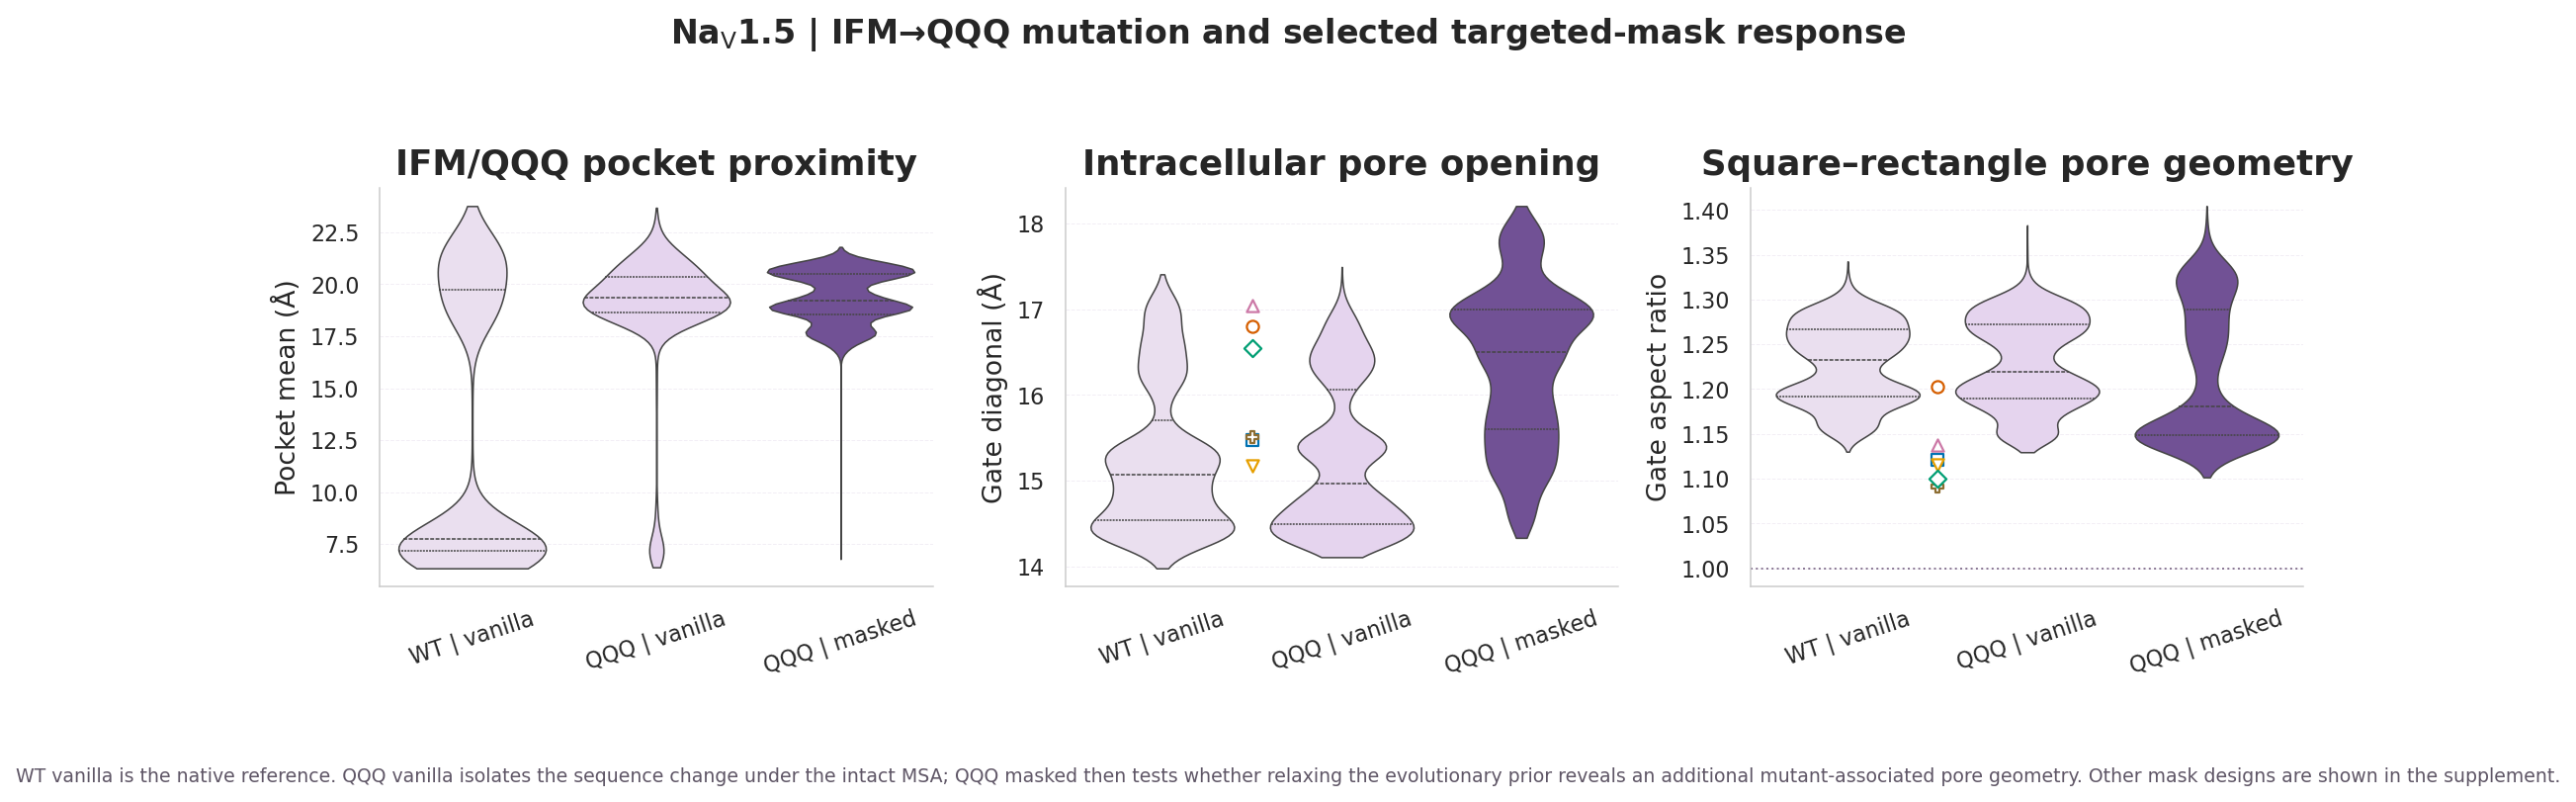

In [3]:
fig=plot_main_mask_tradeoff(summary,models,palette,experimental_shape)
fig.savefig(figure_dir/'Nav15_main_selected_mask_distances.png',dpi=600,bbox_inches='tight')
fig.savefig(figure_dir/'Nav15_main_selected_mask_distances.pdf',bbox_inches='tight')
plt.show()

## Main Figure 2: resemblance to the experimental QQQ/open pore

These panels compare QQQ vanilla directly with the selected original QQQ mask.
RMSD is calculated after alignment to the stable channel core. Lower values mean
that the modeled pore region more closely resembles the corresponding region of
7FBS. The DII-S6 panel is especially informative because it contains the
largest mask-associated improvement.

In [ ]:
rmsd_source=repo_root/'nav15'/'dataRMSD'/'Nav15_all_models_all_references_RMSD_distances_OK3.csv'
rmsd_columns=[
    'sequence_condition','protocol','reference_id','pdb_file',
    'pore_domain__ca__core_aligned_rmsd_A',
    'DII_s6__ca__core_aligned_rmsd_A',
]
rmsd=pd.read_csv(rmsd_source,usecols=rmsd_columns,low_memory=False)
fig=plot_selected_qqq_rmsd(rmsd,palette)
fig.savefig(figure_dir/'Nav15_main_QQQ_7FBS_RMSD.png',dpi=600,bbox_inches='tight')
fig.savefig(figure_dir/'Nav15_main_QQQ_7FBS_RMSD.pdf',bbox_inches='tight')
plt.show()

## Main Figure 3: paired experimental-reference preference

For each model, the signed score is

$$\Delta_{7FBS-8VYJ}=RMSD_{7FBS}-RMSD_{8VYJ}.$$

Negative values indicate a pore closer to the engineered QQQ/open 7FBS
reference; positive values indicate a pore closer to the native-open 8VYJ
reference. This is a structural resemblance score, not a direct functional-state
assignment.

In [ ]:
from shared.rmsd_analysis import reference_preference
preference=reference_preference(rmsd,'pore_domain__ca__core_aligned_rmsd_A','8VYJ','7FBS')
fig=plot_selected_qqq_reference_preference(preference,palette)
fig.savefig(figure_dir/'Nav15_main_QQQ_reference_preference.png',dpi=600,bbox_inches='tight')
fig.savefig(figure_dir/'Nav15_main_QQQ_reference_preference.pdf',bbox_inches='tight')
plt.show()

## Supplemental Figure S1: all mask designs

All WT and QQQ masking profiles are retained here to show sensitivity to mask design. This
includes masked v2 and the WT no-IFM control, which are deliberately excluded
from the main-text comparison.

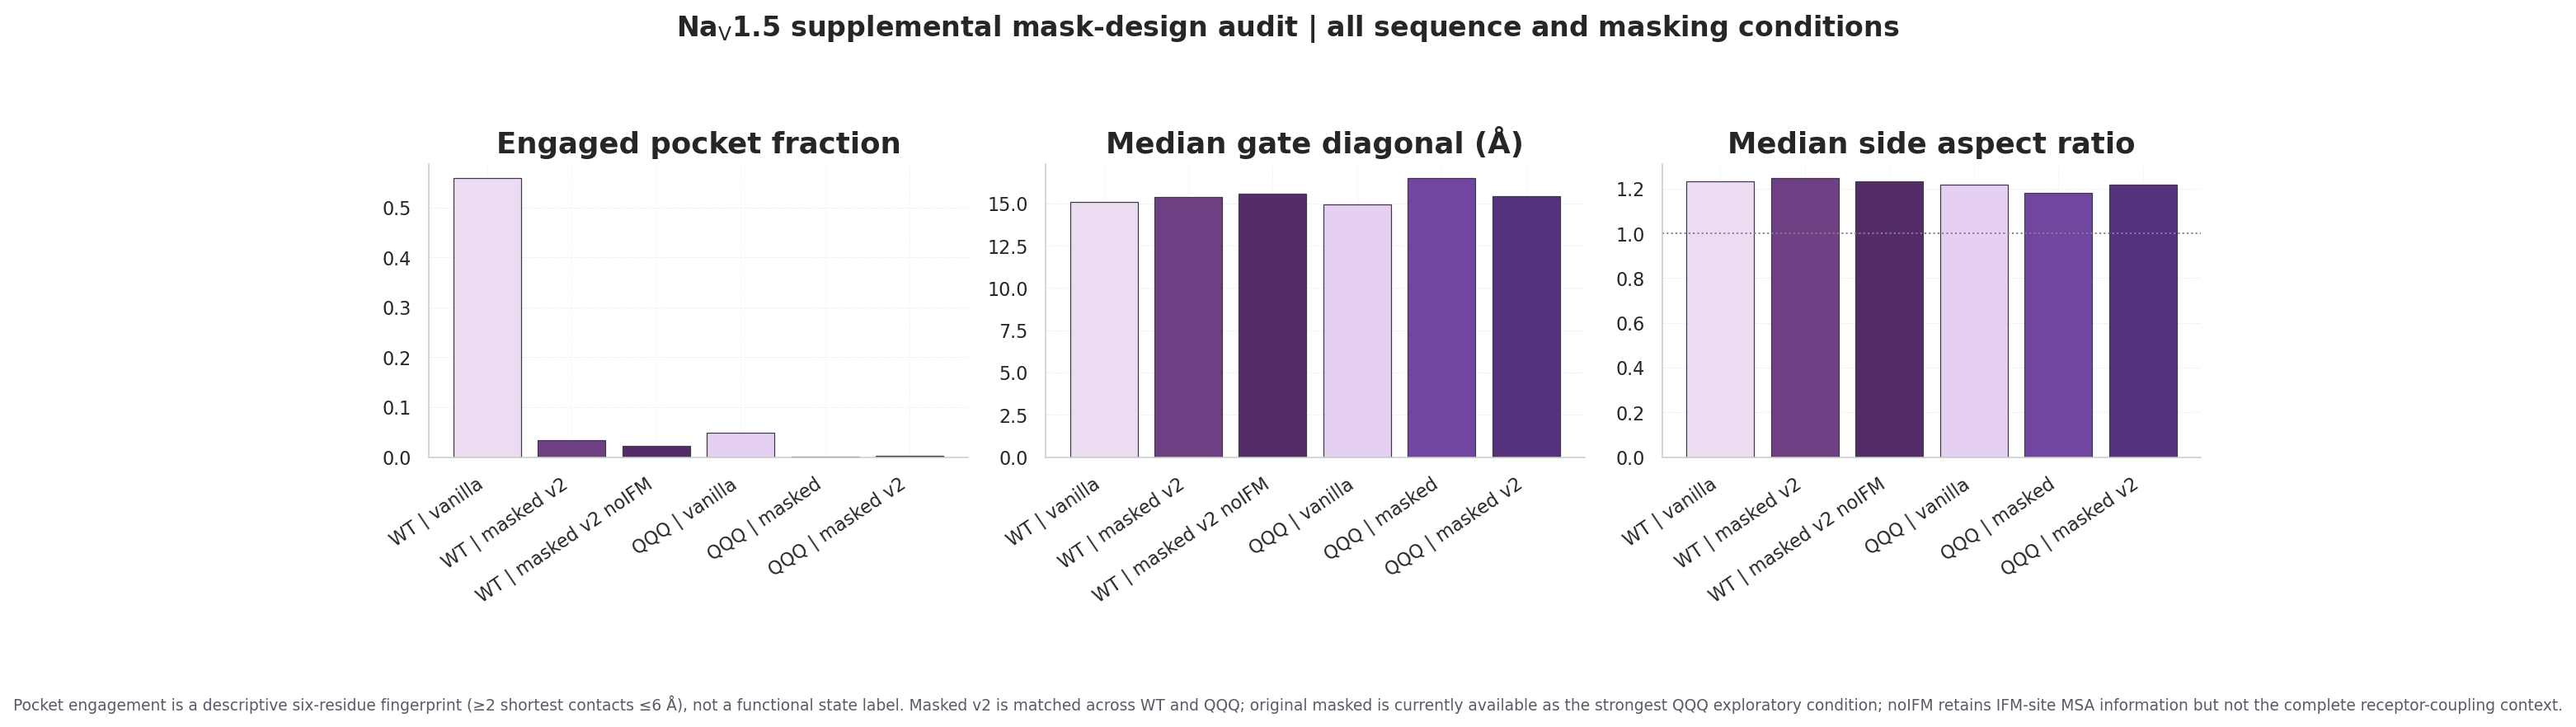

In [12]:
fig=plot_supplemental_mask_audit(summary,palette)
fig.savefig(figure_dir/'Nav15_supplement_mask_audit.png',dpi=300,bbox_inches='tight')
fig.savefig(figure_dir/'Nav15_supplement_mask_audit.pdf',bbox_inches='tight')
plt.show()

## Supplemental figure S2: receptor-pocket profile

The heatmap shows which receptor contacts are retained or lost rather than reducing engagement to a single binary label.

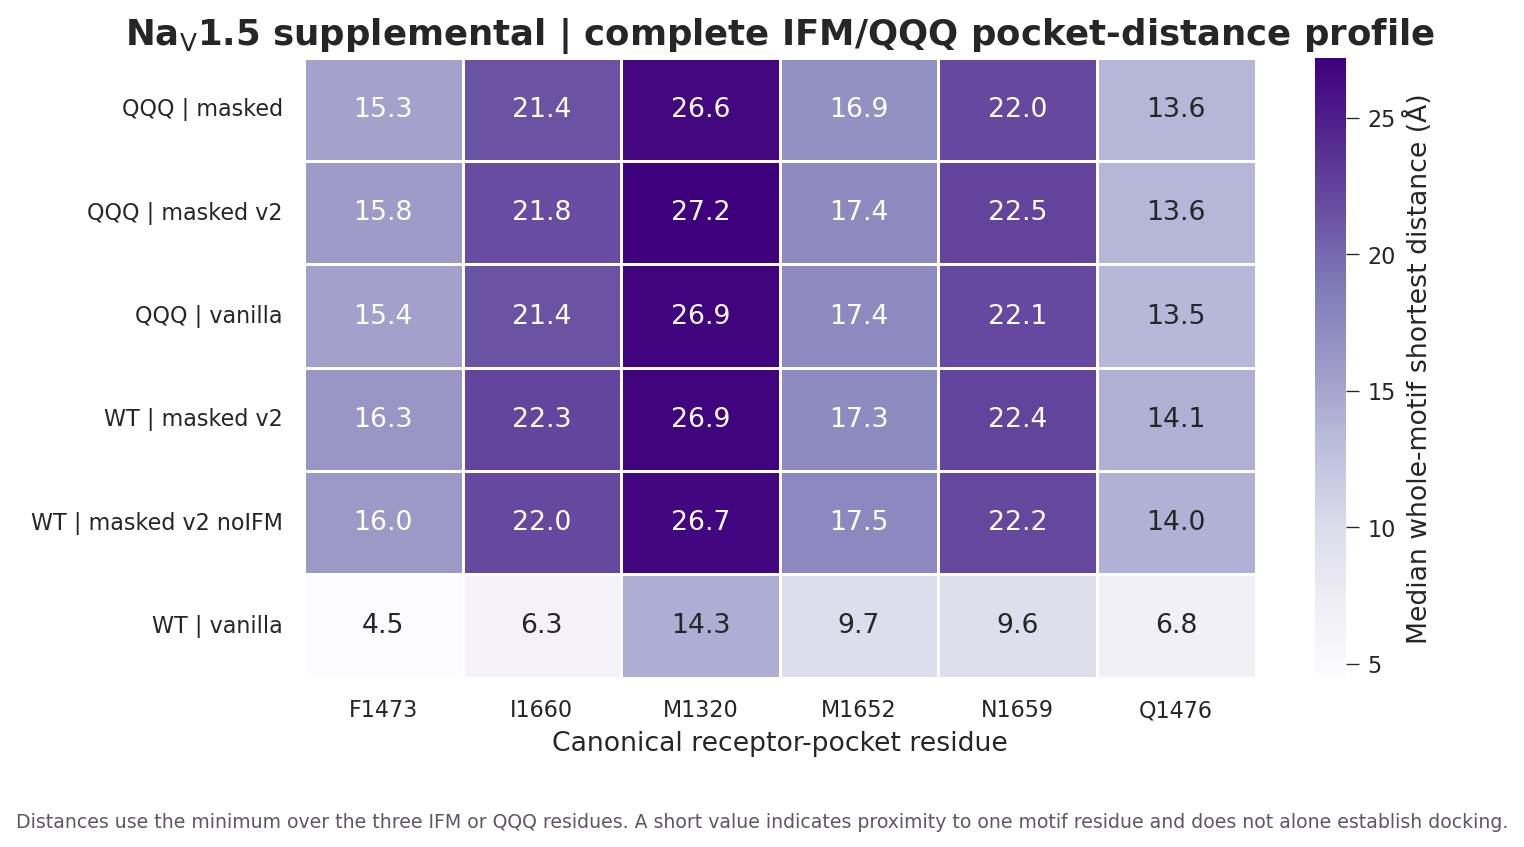

In [13]:
pocket_table,fig=plot_supplemental_pocket_profile(datasets)
fig.savefig(figure_dir/'Nav15_supplement_pocket_profile.png',dpi=300,bbox_inches='tight')
fig.savefig(figure_dir/'Nav15_supplement_pocket_profile.pdf',bbox_inches='tight')
plt.show()
summary.to_csv(repo_root/'nav15/dataRMSD/analysis/presentation/Nav15_mask_presentation_summary.csv',index=False)